In [29]:

# train autoencoder for classification with no compression in the bottleneck layer
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.utils import plot_model
from matplotlib import pyplot
import os
import numpy as np
import pandas as pd


In [30]:
# run script from the data_input file
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("momentum_labeled.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','trend_bin']]
df_factor = df_factor.set_index('Date')

df_curve = pd.read_csv("curve_features.csv", parse_dates=['Date'])
df_curve = df_curve.set_index('Date')


df_additional = pd.read_csv("additional_features.csv", parse_dates=['Date'])
df_additional = df_additional.set_index('Date')

data = pd.concat([df_curve,df_additional,df_factor], axis=1, join='inner')
data = data.fillna(data.mean())
data = data.iloc[:-2]

print(data)

            SA_NB_Level  SA_NB_Slope  SA_NB_Curvature  SA_NB_Lambda  SA_NB_R2  \
Date                                                                            
2004-02-01     9.306546    -2.418051        -3.796823          1.37  0.822204   
2004-03-01     9.306546    -2.418051        -3.796823          1.37  0.822204   
2004-04-01     9.306546    -2.418051        -3.796823          1.37  0.822204   
2004-05-01     9.306546    -2.418051        -3.796823          1.37  0.822204   
2004-06-01     9.306546    -2.418051        -3.796823          1.37  0.822204   
...                 ...          ...              ...           ...       ...   
2023-06-01    12.798354    -4.225769        -4.779430          1.37  0.791609   
2023-07-01    12.070592    -2.914046        -5.148850          1.37  0.637257   
2023-08-01    11.832468    -2.656393        -5.225939          1.37  0.586967   
2023-09-01    12.382199    -3.245188        -7.317326          1.37  0.689729   
2023-10-01    13.074189    -

In [31]:
X = data.iloc[:, :-1].values
X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)  # Convert inf to large finite numbers
   
y = data.iloc[:, -1].values
n_inputs = X.shape[1]

# split into train test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
# scale data
t = MinMaxScaler()
t.fit(X_train)
X_train = t.transform(X_train)
X_test = t.transform(X_test)
print(y)


[0. 1. 1. 1. 0. 1. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 1.
 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 1. 0. 0. 0.
 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [32]:
# define encoder
visible = Input(shape=(n_inputs,))
# encoder level 1
e = Dense(n_inputs*2)(visible)
e = BatchNormalization()(e)
e = LeakyReLU()(e)
# encoder level 2
e = Dense(n_inputs)(e)
e = BatchNormalization()(e)
e = LeakyReLU()(e)
# bottleneck
n_bottleneck = round(float(n_inputs) / 2.0)
bottleneck = Dense(n_bottleneck)(e)
# define decoder, level 1
d = Dense(n_inputs)(bottleneck)
d = BatchNormalization()(d)
d = LeakyReLU()(d)
# decoder level 2
d = Dense(n_inputs*2)(d)
d = BatchNormalization()(d)
d = LeakyReLU()(d)
# output layer
output = Dense(n_inputs, activation='linear')(d)
# define autoencoder model
model = Model(inputs=visible, outputs=output)
# compile autoencoder model
model.compile(optimizer='adam', loss='mse')
# plot the autoencoder
plot_model(model, 'autoencoder_compress.png', show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


Epoch 1/200
10/10 - 5s - 480ms/step - loss: 0.5762 - val_loss: 0.2056
Epoch 2/200
10/10 - 0s - 21ms/step - loss: 0.1527 - val_loss: 0.1624
Epoch 3/200
10/10 - 0s - 26ms/step - loss: 0.0891 - val_loss: 0.1578
Epoch 4/200
10/10 - 0s - 49ms/step - loss: 0.0567 - val_loss: 0.1518
Epoch 5/200
10/10 - 0s - 34ms/step - loss: 0.0459 - val_loss: 0.1370
Epoch 6/200
10/10 - 0s - 46ms/step - loss: 0.0428 - val_loss: 0.1135
Epoch 7/200
10/10 - 0s - 33ms/step - loss: 0.0358 - val_loss: 0.1120
Epoch 8/200
10/10 - 0s - 29ms/step - loss: 0.0308 - val_loss: 0.0882
Epoch 9/200
10/10 - 0s - 34ms/step - loss: 0.0319 - val_loss: 0.0881
Epoch 10/200
10/10 - 0s - 38ms/step - loss: 0.0298 - val_loss: 0.0747
Epoch 11/200
10/10 - 0s - 34ms/step - loss: 0.0253 - val_loss: 0.0625
Epoch 12/200
10/10 - 0s - 27ms/step - loss: 0.0261 - val_loss: 0.0546
Epoch 13/200
10/10 - 0s - 21ms/step - loss: 0.0247 - val_loss: 0.0532
Epoch 14/200
10/10 - 0s - 26ms/step - loss: 0.0245 - val_loss: 0.0465
Epoch 15/200
10/10 - 0s - 30

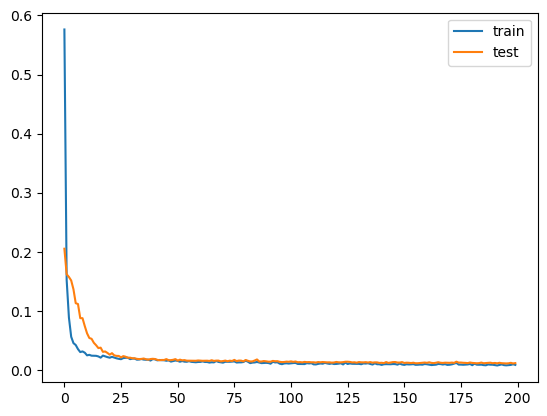

In [33]:
# fit the autoencoder model to reconstruct input
history = model.fit(X_train, X_train, epochs=200, batch_size=16, verbose=2, validation_data=(X_test,X_test))
# plot loss
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [34]:
# define an encoder model (without the decoder)
encoder = Model(inputs=visible, outputs=bottleneck)
plot_model(encoder, 'encoder_compress.png', show_shapes=True)
# save the encoder to file
encoder.save('encoder.h5')

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [35]:
# baseline in performance with logistic regression model
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# define dataset
#X, y = make_classification(n_samples=1000, n_features=100, n_informative=10, n_redundant=90, random_state=1)
# split into train test sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
# scale data
t = MinMaxScaler()
t.fit(X_train)
X_train = t.transform(X_train)
X_test = t.transform(X_test)
# define model
model = LogisticRegression()
# fit model on training set
model.fit(X_train, y_train)
# make prediction on test set
yhat = model.predict(X_test)
# calculate accuracy
acc = accuracy_score(y_test, yhat)
print(acc)

0.6329113924050633


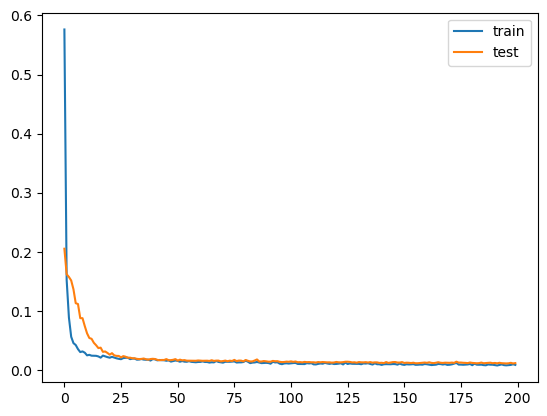

In [36]:
...
# plot loss
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [37]:
...
# define an encoder model (without the decoder)
encoder = Model(inputs=visible, outputs=bottleneck)
plot_model(encoder, 'encoder_no_compress.png', show_shapes=True)
# save the encoder to file
encoder.save('encoder.h5')

You must install pydot (`pip install pydot`) for `plot_model` to work.
